# Natural Language Processing (NLP)

## Complete Reference with Theory, Math, and Practice

From raw text to large language models — this notebook covers the full NLP stack, building intuition for each layer of the pipeline.

---

## Table of Contents

1. [Text Preprocessing](#preprocessing)
2. [Text Representation: BoW & TF-IDF](#bow-tfidf)
3. [Word Embeddings: Word2Vec, GloVe, FastText](#embeddings)
4. [Classical NLP Tasks: POS, NER, Parsing](#classical)
5. [Sentiment Analysis — End-to-End](#sentiment)
6. [Sequence Models for Text (RNN / LSTM)](#seq-models)
7. [Transformers for NLP: BERT & GPT](#transformers-nlp)
8. [Text Generation & Practical Applications](#applications)

---

<a name="preprocessing"></a>
## 1. Text Preprocessing

### Why Preprocessing Matters

Raw text is messy: upper/lower case inconsistencies, punctuation, inflected forms, stopwords. Preprocessing converts text into a **clean, normalised** form that downstream models can handle reliably.

### The Preprocessing Pipeline

```
Raw text → Lowercasing → Tokenisation → Stopword removal → Normalisation (stem/lemma)
```

### Tokenisation

Split text into units (tokens): words, subwords, or characters.

| Type | Example (`"running quickly"`) | Use Case |
|------|-------------------------------|---------|
| Word | `["running", "quickly"]` | Classical NLP |
| Subword (BPE) | `["run", "##ning", "quick", "##ly"]` | Transformers (BERT, GPT) |
| Character | `["r","u","n",...,"y"]` | Morphologically rich languages |

### Stemming vs Lemmatisation

| | Stemming | Lemmatisation |
|--|----------|---------------|
| Method | Rule-based suffix stripping | Dictionary lookup + POS |
| `running` | `run` | `run` |
| `better` | `better` | `good` |
| Speed | Fast | Slower |
| Quality | Rough (can over-stem) | Linguistically correct |

### Stopwords

High-frequency words carrying little semantic content: *the, is, at, which, on, ...*

Removing them reduces vocabulary size and noise for bag-of-words models, but **should not** be removed for transformer models (they use full context).

### Regular Expressions for Text Cleaning

| Pattern | Removes |
|---------|---------|
| `[^a-zA-Z\s]` | Punctuation and digits |
| `\s+` | Extra whitespace |
| `http\S+` | URLs |
| `@\w+` | Twitter handles |
| `#\w+` | Hashtags |

In [1]:
import re
from collections import Counter

# ── Simple preprocessing pipeline (pure Python — no NLTK required) ────────────

STOPWORDS = {
    "i","me","my","we","our","you","your","he","she","it","its","they","their",
    "what","which","who","is","are","was","were","be","been","being","have","has",
    "had","do","does","did","will","would","could","should","may","might","shall",
    "the","a","an","of","in","on","at","by","for","with","about","to","from",
    "and","or","but","not","no","so","than","that","this","these","those"
}

def tokenize(text):
    """Simple whitespace + punctuation tokenizer."""
    return re.findall(r"\b[a-z]+\b", text.lower())

def remove_stopwords(tokens, stopwords=STOPWORDS):
    return [t for t in tokens if t not in stopwords]

def simple_stem(word):
    """Very basic suffix-stripping stemmer."""
    for suffix in ["ing", "tion", "ness", "ly", "ed", "er", "est", "s"]:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word

def preprocess(text, stem=True):
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    if stem:
        tokens = [simple_stem(t) for t in tokens]
    return tokens

# ── Demo ──────────────────────────────────────────────────────────────────────
corpus = [
    "The quick brown fox jumps over the lazy dog!",
    "Running quickly through the forest, the fox was searching for food.",
    "Deep learning models are transforming natural language processing tasks.",
    "NLP techniques include tokenization, stemming, and lemmatization.",
    "Transformers revolutionized the field of natural language understanding.",
]

print("=" * 60)
for i, text in enumerate(corpus):
    tokens = preprocess(text)
    print(f"Doc {i+1}: {tokens}")

# Vocabulary statistics
all_tokens = [t for doc in corpus for t in preprocess(doc, stem=False)]
stemmed    = [t for doc in corpus for t in preprocess(doc, stem=True)]

print(f"\nRaw token count:     {len(all_tokens)}")
print(f"Vocabulary (raw):    {len(set(all_tokens))} unique terms")
print(f"Vocabulary (stemmed):{len(set(stemmed))} unique terms (after stemming)")

print(f"\nTop 10 terms:")
for word, count in Counter(all_tokens).most_common(10):
    print(f"  {word:20s} {count}")

# ── Regex cleaning demo ────────────────────────────────────────────────────────
noisy = "Check out https://example.com! @JohnDoe loves #NLP & ML 😀  !!!  "
cleaned = re.sub(r"http\S+", "", noisy)       # URLs
cleaned = re.sub(r"@\w+", "", cleaned)         # handles
cleaned = re.sub(r"#\w+", "", cleaned)         # hashtags
cleaned = re.sub(r"[^a-zA-Z\s]", "", cleaned) # non-alpha
cleaned = re.sub(r"\s+", " ", cleaned).strip() # whitespace
print(f"\nNoisy text : {noisy!r}")
print(f"Cleaned    : {cleaned!r}")

Doc 1: ['quick', 'brown', 'fox', 'jump', 'over', 'lazy', 'dog']
Doc 2: ['runn', 'quick', 'through', 'for', 'fox', 'search', 'food']
Doc 3: ['deep', 'learn', 'model', 'transform', 'natural', 'language', 'process', 'task']
Doc 4: ['nlp', 'technique', 'include', 'tokeniza', 'stemm', 'lemmatiza']
Doc 5: ['transformer', 'revolutioniz', 'field', 'natural', 'language', 'understand']

Raw token count:     34
Vocabulary (raw):    31 unique terms
Vocabulary (stemmed):30 unique terms (after stemming)

Top 10 terms:
  fox                  2
  natural              2
  language             2
  quick                1
  brown                1
  jumps                1
  over                 1
  lazy                 1
  dog                  1
  running              1

Noisy text : 'Check out https://example.com! @JohnDoe loves #NLP & ML 😀  !!!  '
Cleaned    : 'Check out loves ML'


<a name="bow-tfidf"></a>
## 2. Text Representation: Bag-of-Words & TF-IDF

### Bag of Words (BoW)

Each document becomes a **count vector** over the full vocabulary:

$$\mathbf{x}_d = [c_1, c_2, \ldots, c_{|V|}] \quad \text{where } c_i = \text{count of word } i \text{ in doc } d$$

**Limitations:** Ignores word order; a word like *"the"* dominates even after stopword removal.

### TF-IDF: Term Frequency — Inverse Document Frequency

Weight each term by how distinctive it is to a document **relative to the corpus**:

$$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total terms in } d}$$

$$\text{IDF}(t) = \log \frac{N}{1 + |\{d : t \in d\}|}$$

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Where $N$ is the total number of documents. The $+1$ in the denominator prevents division by zero.

**Intuition:**
- High TF: term appears often in this document → likely important
- High IDF: term appears in few documents → distinctive (not a common word)
- Low IDF: term appears in almost all documents → uninformative

### Cosine Similarity

Compare two document vectors:

$$\text{cosine}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$$

Range: $[-1, 1]$, but always $[0, 1]$ for count vectors (no negatives). Value 1 = same direction = similar documents.

### N-grams

Extend BoW to capture short word sequences:

| N | Type | Example tokens from *"deep learning works"* |
|---|------|----------------------------------------------|
| 1 | Unigram | `deep`, `learning`, `works` |
| 2 | Bigram | `deep learning`, `learning works` |
| 3 | Trigram | `deep learning works` |

N-grams preserve some local context at the cost of larger vocabulary.

Vocabulary size: 28
BoW matrix shape: (5, 28)

Top TF-IDF terms per document:
  Doc 1: [('machine', 0.183), ('artificial', 0.183), ('subset', 0.183), ('intelligence', 0.183)]
  Doc 2: [('learn', 0.115), ('uses', 0.115), ('data', 0.115), ('deep', 0.115)]
  Doc 3: [('language', 0.305), ('deals', 0.153), ('processing', 0.153), ('human', 0.153)]
  Doc 4: [('vision', 0.131), ('computer', 0.131), ('processes', 0.131), ('images', 0.131)]
  Doc 5: [('agents', 0.131), ('trains', 0.131), ('through', 0.131), ('rewards', 0.131)]


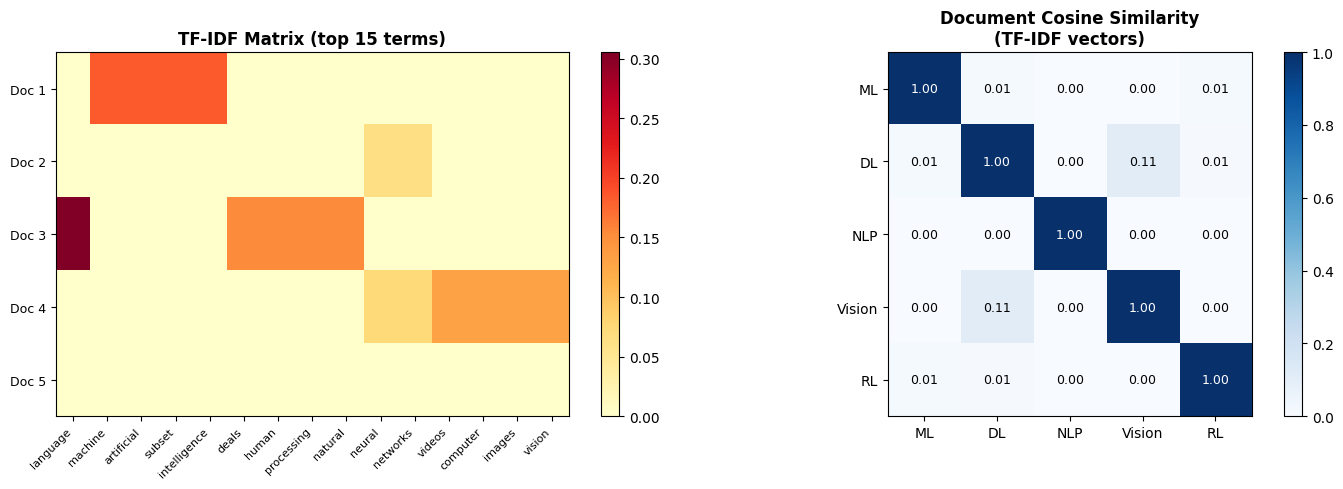


Unigrams: ['deep', 'learning', 'models', 'learn', 'useful', 'representations', 'from', 'raw', 'data']
Bigrams:  ['deep learning', 'learning models', 'models learn', 'learn useful', 'useful representations', 'representations from', 'from raw', 'raw data']
Trigrams: ['deep learning models', 'learning models learn', 'models learn useful', 'learn useful representations', 'useful representations from', 'representations from raw', 'from raw data']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

# ── Bag of Words from scratch ──────────────────────────────────────────────────
STOPWORDS = {"i","me","the","a","an","is","are","was","were","be","been",
             "to","of","in","on","at","and","or","but","not","for","with","this","that"}

def tokenize(text):
    return re.findall(r"\b[a-z]+\b", text.lower())

def remove_sw(tokens):
    return [t for t in tokens if t not in STOPWORDS]

corpus = [
    "machine learning is a subset of artificial intelligence",
    "deep learning uses neural networks to learn from data",
    "natural language processing deals with human language",
    "computer vision processes images and videos with neural networks",
    "reinforcement learning trains agents through rewards and penalties",
]

tokenized = [remove_sw(tokenize(d)) for d in corpus]

# Build vocabulary
vocab = sorted(set(w for doc in tokenized for w in doc))
word2idx = {w: i for i, w in enumerate(vocab)}

# BoW matrix
bow = np.zeros((len(corpus), len(vocab)), dtype=int)
for d_idx, doc in enumerate(tokenized):
    for word in doc:
        bow[d_idx, word2idx[word]] += 1

print("Vocabulary size:", len(vocab))
print("BoW matrix shape:", bow.shape)

# ── TF-IDF from scratch ────────────────────────────────────────────────────────
N = len(corpus)
tf  = bow / (bow.sum(axis=1, keepdims=True) + 1e-9)
idf = np.log(N / (1 + (bow > 0).sum(axis=0)))
tfidf = tf * idf

# ── Cosine similarity ──────────────────────────────────────────────────────────
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

sim_matrix = np.array([[cosine_sim(tfidf[i], tfidf[j])
                         for j in range(N)] for i in range(N)])

print("\nTop TF-IDF terms per document:")
for i, doc in enumerate(corpus):
    top_idx = tfidf[i].argsort()[::-1][:4]
    top_terms = [(vocab[j], round(tfidf[i, j], 3)) for j in top_idx if tfidf[i,j] > 0]
    print(f"  Doc {i+1}: {top_terms}")

# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TF-IDF heatmap (top 15 terms)
top_terms_global = tfidf.sum(axis=0).argsort()[::-1][:15]
ax = axes[0]
im = ax.imshow(tfidf[:, top_terms_global], cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(15))
ax.set_xticklabels([vocab[i] for i in top_terms_global], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(N))
ax.set_yticklabels([f"Doc {i+1}" for i in range(N)], fontsize=9)
ax.set_title("TF-IDF Matrix (top 15 terms)", fontweight="bold")
plt.colorbar(im, ax=ax)

# Cosine similarity heatmap
im2 = axes[1].imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(N)); axes[1].set_yticks(range(N))
labels = ["ML", "DL", "NLP", "Vision", "RL"]
axes[1].set_xticklabels(labels); axes[1].set_yticklabels(labels)
axes[1].set_title("Document Cosine Similarity\n(TF-IDF vectors)", fontweight="bold")
plt.colorbar(im2, ax=axes[1])
for i in range(N):
    for j in range(N):
        axes[1].text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center",
                    fontsize=9, color="black" if sim_matrix[i,j] < 0.6 else "white")

plt.tight_layout(); plt.show()

# ── N-gram demo ────────────────────────────────────────────────────────────────
def ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

sample_tokens = tokenize("deep learning models learn useful representations from raw data")
print("\nUnigrams:", ngrams(sample_tokens, 1))
print("Bigrams: ", ngrams(sample_tokens, 2))
print("Trigrams:", ngrams(sample_tokens, 3))

<a name="embeddings"></a>
## 3. Word Embeddings: Word2Vec, GloVe, and FastText

### The Problem with BoW

BoW treats *"king"* and *"queen"* as completely unrelated vectors. We want **semantic geometry**:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

### Dense Word Vectors

Map each word to a dense, low-dimensional vector $\mathbf{v} \in \mathbb{R}^d$ (typically $d = 50$–$300$) where **geometric distance reflects semantic similarity**.

### Word2Vec (Mikolov et al., 2013)

Two architectures, both trained on a simple self-supervised task:

#### Skip-Gram: Predict Context from Centre Word

Given centre word $w_c$, predict surrounding context words $w_o$ in a window of size $2k$:

$$\mathcal{L} = -\sum_t \sum_{-k \le j \le k, j \ne 0} \log P(w_{t+j} \mid w_t)$$

$$P(w_o \mid w_c) = \frac{\exp(\mathbf{u}_{w_o}^T \mathbf{v}_{w_c})}{\sum_{w=1}^{|V|} \exp(\mathbf{u}_w^T \mathbf{v}_{w_c})}$$

Where $\mathbf{v}_{w_c}$ is the **input embedding** and $\mathbf{u}_{w_o}$ is the **output embedding**.

#### CBOW: Predict Centre from Context

Average the context embeddings to predict the centre word — faster but slightly weaker.

#### Negative Sampling

Computing the full softmax over $|V|$ words is expensive. **Negative sampling** approximates it:

$$\mathcal{L}_{\text{NS}} = \log \sigma(\mathbf{u}_{w_o}^T \mathbf{v}_{w_c}) + \sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n}[\log \sigma(-\mathbf{u}_{w_i}^T \mathbf{v}_{w_c})]$$

Only update the target word and $k$ random negative samples per step.

### GloVe (Global Vectors)

Word2Vec uses **local** context windows. GloVe uses the **global co-occurrence matrix** $X_{ij}$ = how often word $i$ appears near word $j$:

$$\mathcal{L} = \sum_{i,j} f(X_{ij}) (\mathbf{v}_i^T \tilde{\mathbf{v}}_j + b_i + \tilde{b}_j - \log X_{ij})^2$$

Where $f(x) = \min(1, (x/x_{\max})^\alpha)$ downweights extremely common co-occurrences.

### FastText

Extends Word2Vec by representing words as sums of **character n-gram embeddings**:

$$\mathbf{v}_{\text{word}} = \sum_{g \in \mathcal{G}(w)} \mathbf{z}_g$$

**Advantage:** Handles **out-of-vocabulary (OOV)** words and morphologically rich languages (e.g., Finnish, Turkish) naturally.

### Comparison

| | Word2Vec | GloVe | FastText |
|--|----------|-------|---------|
| Training data | Local context windows | Global co-occurrence | Local windows on subwords |
| OOV handling | ❌ | ❌ | ✅ |
| Morphology | ❌ | ❌ | ✅ |
| Speed | Fast | Moderate | Slow |
| Typical dim | 100–300 | 50–300 | 100–300 |

Word2Vec trained on 34 vocab, 180 pairs, 20-dim embeddings
Final loss: 1.8847


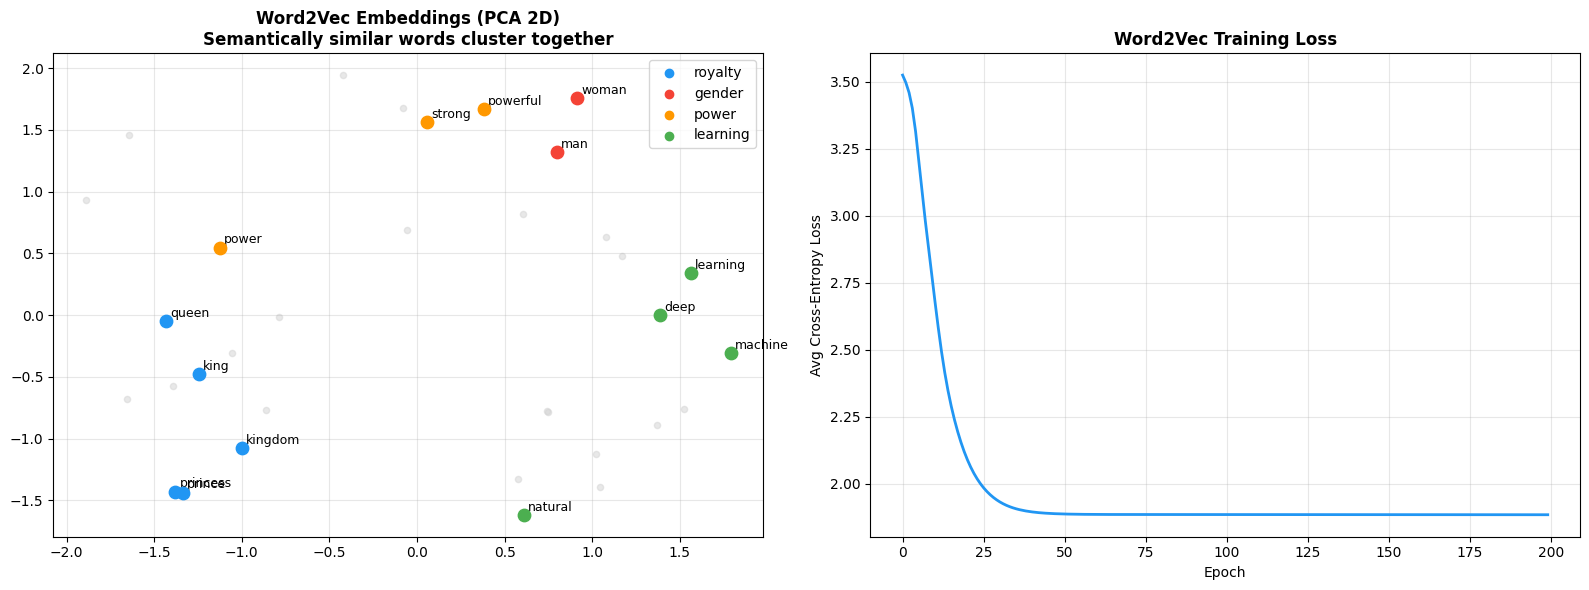


king - man + woman ≈ ?
  wise             sim=0.504
  the              sim=0.48
  rules            sim=0.31
  have             sim=0.276
  kingdom          sim=0.232


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import defaultdict

# ── Word2Vec Skip-Gram from scratch (toy version) ─────────────────────────────
np.random.seed(42)

corpus_raw = [
    "the king rules the kingdom with power",
    "the queen rules the kingdom with grace",
    "the king and queen have power and grace",
    "man is strong and powerful",
    "woman is graceful and wise",
    "the prince will become king",
    "the princess will become queen",
    "deep learning is a powerful technique",
    "natural language processing uses deep learning",
    "machine learning models learn from data",
]

def tokenize(text):
    return re.findall(r"\b[a-z]+\b", text.lower())

tokenized = [tokenize(s) for s in corpus_raw]
vocab = sorted(set(w for s in tokenized for w in s))
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
V = len(vocab)
D = 20       # embedding dimension
WINDOW = 2

# Build training pairs (centre, context)
pairs = []
for sentence in tokenized:
    for center_idx, center in enumerate(sentence):
        for offset in range(-WINDOW, WINDOW+1):
            ctx_idx = center_idx + offset
            if offset == 0 or ctx_idx < 0 or ctx_idx >= len(sentence):
                continue
            pairs.append((w2i[center], w2i[sentence[ctx_idx]]))

# ── One-hot training ────────────────────────────────────────────────────────────
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

W1 = np.random.randn(V, D) * 0.1   # input embeddings  (V, D)
W2 = np.random.randn(D, V) * 0.1   # output embeddings (D, V)

lr = 0.05
losses = []
for epoch in range(200):
    epoch_loss = 0
    for center, context in pairs:
        # Forward
        h   = W1[center]              # (D,)  — embedding lookup
        u   = W2.T @ h                # (V,)  — output scores
        y_hat = softmax(u)            # (V,)

        # Loss (cross-entropy)
        epoch_loss -= np.log(y_hat[context] + 1e-9)

        # Backward
        dy = y_hat.copy(); dy[context] -= 1  # (V,)
        dW2 = np.outer(h, dy)                 # (D, V)
        dh  = W2 @ dy                         # (D,)
        W1[center] -= lr * dh
        W2 -= lr * dW2

    losses.append(epoch_loss / len(pairs))

print(f"Word2Vec trained on {V} vocab, {len(pairs)} pairs, {D}-dim embeddings")
print(f"Final loss: {losses[-1]:.4f}")

# ── Visualise embeddings with PCA ──────────────────────────────────────────────
embeddings = W1  # (V, D)

# PCA: project to 2D
mean = embeddings.mean(axis=0)
centered = embeddings - mean
U, S, Vt = np.linalg.svd(centered, full_matrices=False)
coords_2d = centered @ Vt[:2].T     # (V, 2)

# Words to highlight
highlight_groups = {
    "royalty":   ["king", "queen", "prince", "princess", "kingdom"],
    "gender":    ["man", "woman"],
    "power":     ["power", "powerful", "strong"],
    "learning":  ["deep", "machine", "learning", "natural"],
}
colors = {"royalty": "#2196F3", "gender": "#F44336", "power": "#FF9800", "learning": "#4CAF50"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter all words
axes[0].scatter(coords_2d[:, 0], coords_2d[:, 1], color="lightgray", s=20, alpha=0.5)
for group, words in highlight_groups.items():
    for word in words:
        if word in w2i:
            i = w2i[word]
            axes[0].scatter(*coords_2d[i], color=colors[group], s=80, zorder=5)
            axes[0].annotate(word, coords_2d[i], fontsize=9,
                            xytext=(3, 3), textcoords="offset points")

axes[0].set_title("Word2Vec Embeddings (PCA 2D)\nSemantically similar words cluster together",
                   fontweight="bold")
axes[0].grid(alpha=0.3)
for g, c in colors.items():
    axes[0].scatter([], [], color=c, label=g)
axes[0].legend()

# Training loss
axes[1].plot(losses, color="#2196F3", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Cross-Entropy Loss")
axes[1].set_title("Word2Vec Training Loss", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── Analogy arithmetic ─────────────────────────────────────────────────────────
def nearest(vec, top_n=5, exclude=()):
    """Find nearest words by cosine similarity."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    sims  = (embeddings / norms) @ (vec / (np.linalg.norm(vec) + 1e-9))
    ranked = sims.argsort()[::-1]
    return [(i2w[i], round(sims[i], 3)) for i in ranked if i2w[i] not in exclude][:top_n]

if all(w in w2i for w in ["king", "man", "woman"]):
    analogy = embeddings[w2i["king"]] - embeddings[w2i["man"]] + embeddings[w2i["woman"]]
    print("\nking - man + woman ≈ ?")
    for word, score in nearest(analogy, top_n=5, exclude={"king","man","woman"}):
        print(f"  {word:15s}  sim={score}")

<a name="classical"></a>
## 4. Classical NLP Tasks

### Part-of-Speech (POS) Tagging

Assign a grammatical role to each token:

```
"The quick brown fox jumps"
 DT   JJ    JJ    NN    VBZ
```

| Tag | Meaning | Example |
|-----|---------|---------|
| NN | Noun | *dog, city* |
| VBZ | Verb, 3rd person singular present | *runs, jumps* |
| JJ | Adjective | *quick, brown* |
| DT | Determiner | *the, a* |
| RB | Adverb | *quickly, never* |
| IN | Preposition | *in, on, at* |

**Approaches:**
- **Rule-based**: hand-crafted suffix rules (*-ing → VBG, -ed → VBD*)
- **Statistical HMM**: Viterbi decoding over tag sequences
- **Neural**: BiLSTM or Transformer encoder → per-token classifier

### Named Entity Recognition (NER)

Identify and classify entities in text:

```
"Barack Obama was born in Hawaii in 1961."
  B-PER  I-PER             B-LOC     B-DATE
```

**BIO tagging scheme:**
- `B-X`: Beginning of entity type X
- `I-X`: Inside entity type X (continuation)
- `O`: Outside any entity

**Entity types:** PER (Person), ORG (Organisation), LOC (Location), DATE, MONEY, ...

### Dependency Parsing

Identify grammatical relationships between words:

```
"The cat sat on the mat"
       sat
      / |  \
   cat  on  (ROOT)
   |     \
  The    mat
          |
         the
```

**Key relations:** subject (`nsubj`), object (`dobj`), modifier (`amod`), preposition (`prep`)

### Evaluation Metrics for Sequence Tasks

All three tasks use **token-level** metrics:

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}, \quad F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

For NER: **entity-level** evaluation (all tokens in a span must be correct).

In [4]:
import re

# ── Rule-based POS tagger (simplified suffix rules) ───────────────────────────
POS_RULES = [
    (r"\b(the|a|an|this|that|these|those)\b", "DT"),
    (r"\b\w+ing\b", "VBG"),
    (r"\b\w+ed\b", "VBD"),
    (r"\b\w+ly\b", "RB"),
    (r"\b\w+tion\b", "NN"),
    (r"\b\w+ness\b", "NN"),
    (r"\b\w+ment\b", "NN"),
    (r"\b\w+er\b", "JJR"),        # comparative
    (r"\b\w+est\b", "JJS"),       # superlative
    (r"\b(is|are|was|were|be|been|being)\b", "VBZ"),
    (r"\b(in|on|at|by|for|with|about|to|from|of)\b", "IN"),
    (r"\b(and|or|but)\b", "CC"),
    (r"\b[A-Z][a-z]+\b", "NNP"),  # proper noun (capitalised)
    (r"\b\d+\b", "CD"),           # cardinal number
]

def rule_pos(sentence):
    tokens = sentence.split()
    tags = []
    for token in tokens:
        tag = "NN"   # default: noun
        for pattern, pos in POS_RULES:
            if re.fullmatch(pattern, token, re.IGNORECASE):
                tag = pos
                break
        tags.append((token, tag))
    return tags

sentences = [
    "The quick brown fox jumped over the lazy dog",
    "Deep learning is transforming natural language processing",
    "Barack Obama was born in Hawaii in 1961",
    "She runs quickly through the beautiful forest",
]

for sent in sentences:
    tagged = rule_pos(sent)
    print(" | ".join(f"{w}/{t}" for w, t in tagged))

# ── Rule-based NER (pattern matching) ─────────────────────────────────────────
NER_PATTERNS = [
    (r"\b(Barack Obama|Donald Trump|Joe Biden|Angela Merkel)\b", "PER"),
    (r"\b(Google|Apple|Microsoft|Amazon|Tesla|OpenAI)\b", "ORG"),
    (r"\b(New York|London|Paris|Tokyo|Hawaii|Berlin|California)\b", "LOC"),
    (r"\b(\d{4})\b", "DATE"),
    (r"\$[\d,]+(?:\.\d{2})?", "MONEY"),
]

def rule_ner(text):
    entities = []
    for pattern, etype in NER_PATTERNS:
        for match in re.finditer(pattern, text):
            entities.append((match.group(), etype, match.start(), match.end()))
    entities.sort(key=lambda x: x[2])
    return entities

test_texts = [
    "Barack Obama was born in Hawaii in 1961.",
    "Google and Apple are competing in the New York market.",
    "Tesla raised $1000000000 to expand its Berlin factory in 2023.",
]

print("\nNamed Entity Recognition:")
for text in test_texts:
    entities = rule_ner(text)
    print(f"\n  Text: {text}")
    for ent, etype, start, end in entities:
        print(f"    [{etype:6s}] '{ent}'")

# ── Evaluation metrics ────────────────────────────────────────────────────────
def f1_score(tp, fp, fn):
    p = tp / (tp + fp + 1e-9)
    r = tp / (tp + fn + 1e-9)
    f1 = 2 * p * r / (p + r + 1e-9)
    return p, r, f1

# Simulated NER results
print("\nEvaluation metrics example:")
results = [("PER", 18, 2, 3), ("ORG", 12, 4, 5), ("LOC", 20, 1, 2)]
for label, tp, fp, fn in results:
    p, r, f1 = f1_score(tp, fp, fn)
    print(f"  {label}: P={p:.2f}  R={r:.2f}  F1={f1:.2f}")

The/DT | quick/NNP | brown/NNP | fox/NNP | jumped/VBD | over/JJR | the/DT | lazy/NNP | dog/NNP
Deep/NNP | learning/VBG | is/VBZ | transforming/VBG | natural/NNP | language/NNP | processing/VBG
Barack/NNP | Obama/NNP | was/VBZ | born/NNP | in/IN | Hawaii/NNP | in/IN | 1961/CD
She/NNP | runs/NNP | quickly/RB | through/NNP | the/DT | beautiful/NNP | forest/JJS

Named Entity Recognition:

  Text: Barack Obama was born in Hawaii in 1961.
    [PER   ] 'Barack Obama'
    [LOC   ] 'Hawaii'
    [DATE  ] '1961'

  Text: Google and Apple are competing in the New York market.
    [ORG   ] 'Google'
    [ORG   ] 'Apple'
    [LOC   ] 'New York'

  Text: Tesla raised $1000000000 to expand its Berlin factory in 2023.
    [ORG   ] 'Tesla'
    [MONEY ] '$1000000000'
    [LOC   ] 'Berlin'
    [DATE  ] '2023'

Evaluation metrics example:
  PER: P=0.90  R=0.86  F1=0.88
  ORG: P=0.75  R=0.71  F1=0.73
  LOC: P=0.95  R=0.91  F1=0.93


<a name="sentiment"></a>
## 5. Sentiment Analysis — End-to-End

### Problem Definition

Classify the **emotional polarity** of text:

| Input | Output |
|-------|--------|
| *"This movie was absolutely fantastic!"* | Positive |
| *"Terrible service, I want a refund."* | Negative |
| *"The food was okay, nothing special."* | Neutral |

### Approaches

| Method | How | Strengths | Weaknesses |
|--------|-----|-----------|-----------|
| **Lexicon-based** | Count positive/negative words from a dictionary | Fast, no training data | Misses context, sarcasm |
| **BoW + classifier** | TF-IDF features → Naive Bayes / Logistic Regression | Simple, interpretable | No word order, no semantics |
| **Word embeddings + NN** | Pre-trained embeddings → MLP/CNN | Captures semantics | Ignores position in short texts |
| **LSTM** | Sequential text → hidden state → classifier | Order-aware | Slow, vanishing gradients |
| **Transformer (BERT)** | Fine-tune pre-trained encoder | State-of-the-art | Large compute |

### Naive Bayes for Text Classification

Based on Bayes' theorem with conditional independence assumption:

$$P(c \mid \mathbf{d}) \propto P(c) \prod_{i=1}^{n} P(w_i \mid c)$$

With Laplace (add-$\alpha$) smoothing:

$$P(w \mid c) = \frac{\text{count}(w, c) + \alpha}{\sum_{w'}\text{count}(w', c) + \alpha |V|}$$

**Log space** to avoid numerical underflow:

$$\log P(c \mid \mathbf{d}) \propto \log P(c) + \sum_i \log P(w_i \mid c)$$

### Handling Negation

*"not good"* should map to negative, but BoW sees *"not"* and *"good"* separately.

**Fix:** append `_NEG` to tokens following *not/no/never* until a punctuation marker:

```
"not good" → ["not", "good_NEG"]
"I do not like this" → ["I", "do", "not", "like_NEG", "this_NEG"]
```

Naive Bayes Sentiment Analysis
  ✗ [NEG] Amazing special effects and superb direction...
  ✗ [NEG] The movie was absolutely fantastic and I loved every mi...
  ✗ [NEG] The plot was clever and the characters were memorable...
  ✗ [POS] Very disappointing nothing worked in this film...

Accuracy: 0/4 = 0%

Lexicon-based vs Naive Bayes comparison:
  Naive Bayes accuracy: 71%
  Lexicon   accuracy: 100%


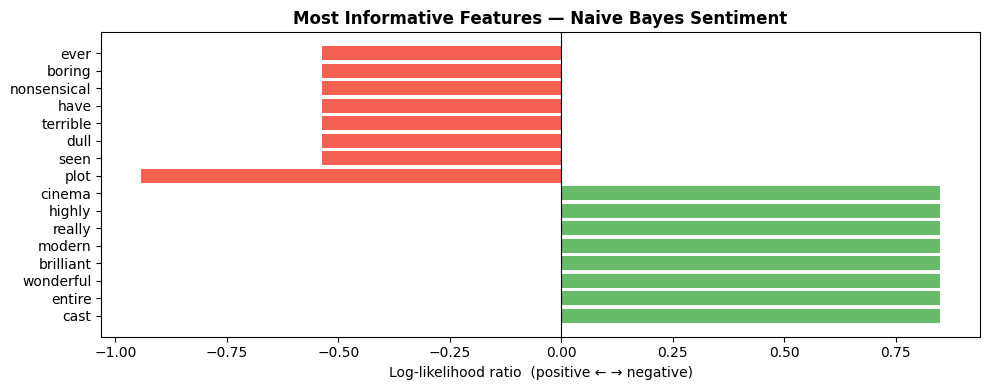

In [5]:
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# ── Toy sentiment dataset ──────────────────────────────────────────────────────
data = [
    # (text, label)  0 = negative, 1 = positive
    ("The movie was absolutely fantastic and I loved every minute", 1),
    ("Great acting and a brilliant storyline", 1),
    ("I really enjoyed this film it was wonderful", 1),
    ("Amazing special effects and superb direction", 1),
    ("A masterpiece of modern cinema highly recommended", 1),
    ("The plot was clever and the characters were memorable", 1),
    ("Incredible performances from the entire cast", 1),
    ("Terrible film waste of time and money", 0),
    ("Boring plot with awful acting I hated it", 0),
    ("The worst movie I have ever seen", 0),
    ("Dull characters and a predictable storyline", 0),
    ("Poorly written script and bad direction", 0),
    ("Very disappointing nothing worked in this film", 0),
    ("Dreadful performances and a nonsensical plot", 0),
]

# Shuffle and split
np.random.seed(0)
idx = np.random.permutation(len(data))
train_data = [data[i] for i in idx[:10]]
test_data  = [data[i] for i in idx[10:]]

STOPWORDS = {"i","me","the","a","an","is","are","was","were","and","or","of","in","it","this","with"}

def tokenize(text):
    return [w for w in re.findall(r"\b[a-z]+\b", text.lower()) if w not in STOPWORDS]

def handle_negation(tokens):
    """Append _NEG to tokens following 'not/no/never'."""
    result, negating = [], False
    for t in tokens:
        if t in ("not", "no", "never"):
            negating = True
            result.append(t)
        elif negating:
            result.append(t + "_NEG")
        else:
            result.append(t)
    return result

# ── Naive Bayes Classifier ─────────────────────────────────────────────────────
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_log_prior = {}
        self.word_log_lik = {}
        self.vocab = set()

    def fit(self, docs, labels):
        classes = set(labels)
        N = len(docs)
        self.word_counts = {c: defaultdict(int) for c in classes}
        self.class_total  = defaultdict(int)
        self.class_counts = Counter(labels)

        for doc, label in zip(docs, labels):
            tokens = handle_negation(tokenize(doc))
            self.vocab.update(tokens)
            for t in tokens:
                self.word_counts[label][t] += 1
                self.class_total[label]    += 1

        V = len(self.vocab)
        a = self.alpha
        self.class_log_prior = {c: np.log(self.class_counts[c] / N) for c in classes}
        self.word_log_lik = {}
        for c in classes:
            total = self.class_total[c]
            self.word_log_lik[c] = {
                w: np.log((self.word_counts[c][w] + a) / (total + a * V))
                for w in self.vocab
            }
            # OOV fallback
            self.word_log_lik[c]["__OOV__"] = np.log(a / (total + a * V))

    def predict(self, doc):
        tokens = handle_negation(tokenize(doc))
        scores = {}
        for c in self.class_counts:
            score = self.class_log_prior[c]
            for t in tokens:
                key = t if t in self.word_log_lik[c] else "__OOV__"
                score += self.word_log_lik[c][key]
            scores[c] = score
        return max(scores, key=scores.get), scores

model = NaiveBayes(alpha=1.0)
model.fit([d[0] for d in train_data], [d[1] for d in train_data])

# ── Evaluate ───────────────────────────────────────────────────────────────────
print("Naive Bayes Sentiment Analysis\n" + "="*40)
correct = 0
for text, true_label in test_data:
    pred, scores = model.predict(text)
    correct += (pred == true_label)
    sentiment = "POS" if pred == 1 else "NEG"
    marker = "✓" if pred == true_label else "✗"
    print(f"  {marker} [{sentiment}] {text[:55]}...")

print(f"\nAccuracy: {correct}/{len(test_data)} = {correct/len(test_data):.0%}")

# ── Lexicon-based approach ─────────────────────────────────────────────────────
POS_WORDS = {"great","good","excellent","fantastic","amazing","wonderful","brilliant",
             "superb","incredible","masterpiece","enjoyed","loved","recommended",
             "clever","memorable","performances"}
NEG_WORDS = {"terrible","bad","awful","worst","boring","dull","poor","disappointing",
             "dreadful","hated","waste","nonsensical","predictable","poorly"}

def lexicon_sentiment(text):
    tokens = set(tokenize(text))
    pos_score = len(tokens & POS_WORDS)
    neg_score = len(tokens & NEG_WORDS)
    if pos_score > neg_score:   return 1
    elif neg_score > pos_score: return 0
    else:                        return -1  # neutral

print("\nLexicon-based vs Naive Bayes comparison:")
from_nb, from_lex = [], []
for text, true in data:
    nb_pred, _ = model.predict(text)
    lex_pred    = lexicon_sentiment(text)
    from_nb.append(nb_pred == true)
    from_lex.append(lex_pred == true)

print(f"  Naive Bayes accuracy: {sum(from_nb)/len(from_nb):.0%}")
print(f"  Lexicon   accuracy: {sum(from_lex)/len(from_lex):.0%}")

# ── Visualise most informative features ───────────────────────────────────────
pos_logliks = model.word_log_lik[1]
neg_logliks = model.word_log_lik[0]

shared_vocab = [w for w in model.vocab if "_NEG" not in w]
lr_ratios = {w: pos_logliks.get(w, pos_logliks["__OOV__"]) -
                neg_logliks.get(w, neg_logliks["__OOV__"])
             for w in shared_vocab}

top_pos = sorted(lr_ratios, key=lr_ratios.get, reverse=True)[:8]
top_neg = sorted(lr_ratios, key=lr_ratios.get)[:8]
feature_words = top_pos + top_neg
feature_scores= [lr_ratios[w] for w in feature_words]
colors = ["#4CAF50" if s > 0 else "#F44336" for s in feature_scores]

plt.figure(figsize=(10, 4))
plt.barh(feature_words, feature_scores, color=colors, alpha=0.85)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Log-likelihood ratio  (positive ← → negative)")
plt.title("Most Informative Features — Naive Bayes Sentiment", fontweight="bold")
plt.tight_layout(); plt.show()

<a name="rnn"></a>
## 6. Sequence Models for Text

### Recurrent Neural Network (RNN)
A vanilla RNN processes tokens one at a time, carrying a hidden state $\mathbf{h}_t$:

$$\mathbf{h}_t = \tanh(\mathbf{W}_h \mathbf{h}_{t-1} + \mathbf{W}_x \mathbf{x}_t + \mathbf{b})$$

| Symbol | Meaning |
|--------|---------|
| $\mathbf{x}_t$ | One-hot or embedding of token at step $t$ |
| $\mathbf{h}_t \in \mathbb{R}^H$ | Hidden state (memory) |
| $\mathbf{W}_h, \mathbf{W}_x$ | Learnable weight matrices |

**Vanishing gradients** — when the sequence is long the gradient of the loss w.r.t. early inputs shrinks exponentially:  
$$\frac{\partial \mathcal{L}}{\partial \mathbf{h}_0} = \prod_{t=1}^{T} \frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_{t-1}} \approx 0 \quad \text{(when } |\lambda_{\max}(\mathbf{W}_h)| < 1)$$

---

### Long Short-Term Memory (LSTM)
LSTM adds a **cell state** $\mathbf{c}_t$ and three gates to control information flow:

| Gate | Formula | Role |
|------|---------|------|
| Forget | $\mathbf{f}_t = \sigma(\mathbf{W}_f[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f)$ | Erase old memory |
| Input | $\mathbf{i}_t = \sigma(\mathbf{W}_i[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i)$ | Write new info |
| Output | $\mathbf{o}_t = \sigma(\mathbf{W}_o[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o)$ | Read cell state |

Cell and hidden state updates:
$$\tilde{\mathbf{c}}_t = \tanh(\mathbf{W}_c[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c)$$
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t$$
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

---

### Sequence-to-Label vs Sequence-to-Sequence

| Task | Architecture |
|------|-------------|
| Sentiment / Classification | Many-to-one: final $\mathbf{h}_T \to$ softmax |
| NER / POS tagging | Many-to-many: each $\mathbf{h}_t \to$ label |
| Machine translation | Encoder-decoder with attention |

> **GRU** (Gated Recurrent Unit) merges forget and input into a single *update gate* — fewer parameters than LSTM, comparable performance.

$$\mathbf{z}_t = \sigma(\mathbf{W}_z[\mathbf{h}_{t-1}, \mathbf{x}_t]), \quad
\mathbf{r}_t = \sigma(\mathbf{W}_r[\mathbf{h}_{t-1}, \mathbf{x}_t])$$
$$\mathbf{h}_t = (1-\mathbf{z}_t)\odot\mathbf{h}_{t-1} + \mathbf{z}_t\odot\tanh(\mathbf{W}_h[\mathbf{r}_t\odot\mathbf{h}_{t-1}, \mathbf{x}_t])$$

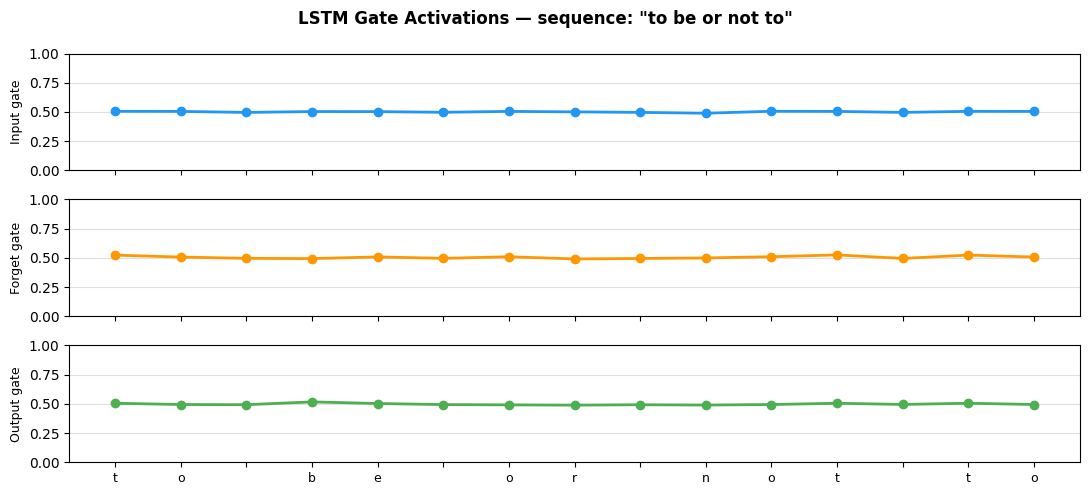

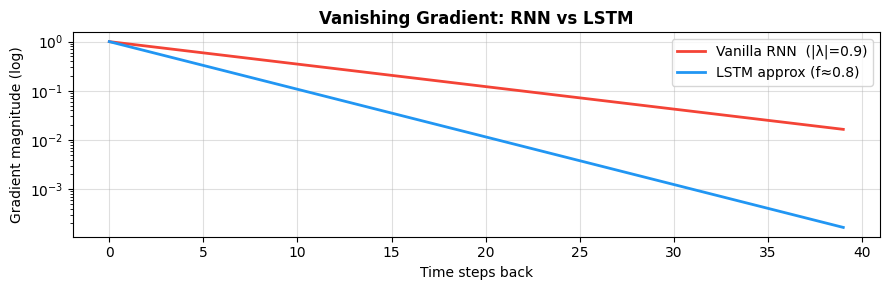

RNN  gradient at t=40 : 1.48e-02
LSTM gradient at t=40 : 1.33e-04  (better, but still decays)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ── Minimal LSTM cell (forward pass only) — pure NumPy ────────────────────────
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -30, 30)))

class LSTMCell:
    """Single LSTM cell. All weights initialised with Xavier uniform."""
    def __init__(self, input_size, hidden_size, seed=42):
        np.random.seed(seed)
        H, I = hidden_size, input_size
        scale = lambda fan_in, fan_out: np.sqrt(6 / (fan_in + fan_out))
        def init(r, c): return np.random.uniform(-scale(r,c), scale(r,c), (r,c))
        # Combined weight matrix for efficiency: [input, hidden] → 4H
        self.W = init(4*H, I+H)
        self.b = np.zeros(4*H)
        self.H = H

    def forward(self, x, h_prev, c_prev):
        xh = np.concatenate([x, h_prev])
        gates = self.W @ xh + self.b  # shape (4H,)
        H = self.H
        i  = sigmoid(gates[0*H : 1*H])
        f  = sigmoid(gates[1*H : 2*H])
        o  = sigmoid(gates[2*H : 3*H])
        c_ = np.tanh(gates[3*H : 4*H])
        c  = f * c_prev + i * c_
        h  = o * np.tanh(c)
        return h, c, dict(i=i, f=f, o=o, c_=c_)

# ── Character-level language model ────────────────────────────────────────────
text = ("to be or not to be that is the question "
        "whether tis nobler in the mind to suffer")
chars  = sorted(set(text))
c2i    = {c: i for i, c in enumerate(chars)}
i2c    = {i: c for c, i in c2i.items()}
V      = len(chars)
SEQ    = 15   # context window
H_SIZE = 32

def one_hot(idx, size):
    v = np.zeros(size); v[idx] = 1.0; return v

# Build (X, y) pairs — predict next character given current
sequences  = [(text[t:t+SEQ], text[t+SEQ]) for t in range(len(text)-SEQ)]
lstm_cell  = LSTMCell(V, H_SIZE)

# Simple manual training loop — SGD on cross-entropy for a few steps
# (Proper BPTT requires storing all gate values; here we show forward pass + inference)
def run_sequence(cell, seq_text):
    h, c = np.zeros(cell.H), np.zeros(cell.H)
    for ch in seq_text:
        x = one_hot(c2i[ch], V)
        h, c, _ = cell.forward(x, h, c)
    return h, c

# ── Visualise gate activations on one sequence ────────────────────────────────
sample_seq = "to be or not to"
h, c0 = np.zeros(H_SIZE), np.zeros(H_SIZE)
gate_trace = {"i": [], "f": [], "o": []}
for ch in sample_seq:
    x = one_hot(c2i.get(ch, c2i[' ']), V)
    h, c0, gates = lstm_cell.forward(x, h, c0)
    for g in gate_trace:
        gate_trace[g].append(gates[g][:8].mean())   # mean over first 8 units

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
gate_info = [("i","Input gate",  "#2196F3"),
             ("f","Forget gate", "#FF9800"),
             ("o","Output gate", "#4CAF50")]
for ax, (key, label, color) in zip(axes, gate_info):
    ax.plot(gate_trace[key], marker="o", color=color, lw=2)
    ax.set_ylabel(label, fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.4)
axes[-1].set_xticks(range(len(sample_seq)))
axes[-1].set_xticklabels(list(sample_seq), fontsize=9)
fig.suptitle(f'LSTM Gate Activations — sequence: "{sample_seq}"', fontweight="bold")
plt.tight_layout(); plt.show()

# ── Gradient flow comparison: Vanilla RNN vs LSTM ─────────────────────────────
T = 40
# RNN: gradient multiplied by W_h each step → explodes/vanishes
rnn_W  = 0.9   # eigenvalue < 1 → vanishing
rnn_grads = [rnn_W**t for t in range(T)]

# LSTM: forget gate ≈ 0.8 moderates the flow
f_val  = 0.8
lstm_grads = [f_val**t for t in range(T)]

plt.figure(figsize=(9, 3))
plt.semilogy(rnn_grads, label=f"Vanilla RNN  (|λ|={rnn_W})", color="#F44336", lw=2)
plt.semilogy(lstm_grads, label=f"LSTM approx (f≈{f_val})",  color="#2196F3", lw=2)
plt.xlabel("Time steps back"); plt.ylabel("Gradient magnitude (log)")
plt.title("Vanishing Gradient: RNN vs LSTM", fontweight="bold")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

print(f"RNN  gradient at t=40 : {rnn_W**40:.2e}")
print(f"LSTM gradient at t=40 : {f_val**40:.2e}  (better, but still decays)")

<a name="transformers"></a>
## 7. Transformers for NLP

### Self-Attention
Every token attends to all other tokens simultaneously — no sequential bottleneck.

$$\text{Attention}(\mathbf{Q},\mathbf{K},\mathbf{V}) = \text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)\mathbf{V}$$

Queries, Keys, Values are linear projections of the input:
$$\mathbf{Q} = \mathbf{X}\mathbf{W}^Q, \quad \mathbf{K} = \mathbf{X}\mathbf{W}^K, \quad \mathbf{V} = \mathbf{X}\mathbf{W}^V$$

The $\sqrt{d_k}$ scaling prevents softmax from entering saturated regions with large $d_k$.

---

### Multi-Head Attention
Run $h$ attention heads in parallel, each learning different relationships:

$$\text{MultiHead}(\mathbf{Q},\mathbf{K},\mathbf{V}) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)\,\mathbf{W}^O$$
$$\text{head}_i = \text{Attention}(\mathbf{X}\mathbf{W}_i^Q, \mathbf{X}\mathbf{W}_i^K, \mathbf{X}\mathbf{W}_i^V)$$

---

### Positional Encoding
Transformers have no recurrence; position is injected via sinusoidal encoding:

$$PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad
PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

---

### Transformer Block
$$\mathbf{Z} = \text{LayerNorm}(\mathbf{X} + \text{MultiHead}(\mathbf{X}))$$
$$\mathbf{Y} = \text{LayerNorm}(\mathbf{Z} + \text{FFN}(\mathbf{Z})), \quad
\text{FFN}(\mathbf{z}) = \max(0, \mathbf{z}\mathbf{W}_1+\mathbf{b}_1)\mathbf{W}_2+\mathbf{b}_2$$

---

### BERT vs GPT

| Property | BERT | GPT |
|----------|------|-----|
| Architecture | Encoder only | Decoder only |
| Training objective | Masked LM + NSP | Autoregressive LM |
| Attention mask | Bidirectional (sees all tokens) | Causal (left-to-right) |
| Pre-training task | Predict masked tokens | Predict next token |
| Best for | Classification, NER, QA | Text generation |

**BPE Tokenisation** (Byte-Pair Encoding):
1. Start with character vocabulary
2. Repeatedly merge the most frequent pair of adjacent symbols
3. Vocabulary size controlled by number of merge operations

> **BERT input** = `[CLS]` token + WordPiece subwords + `[SEP]` + token/segment/positional embeddings

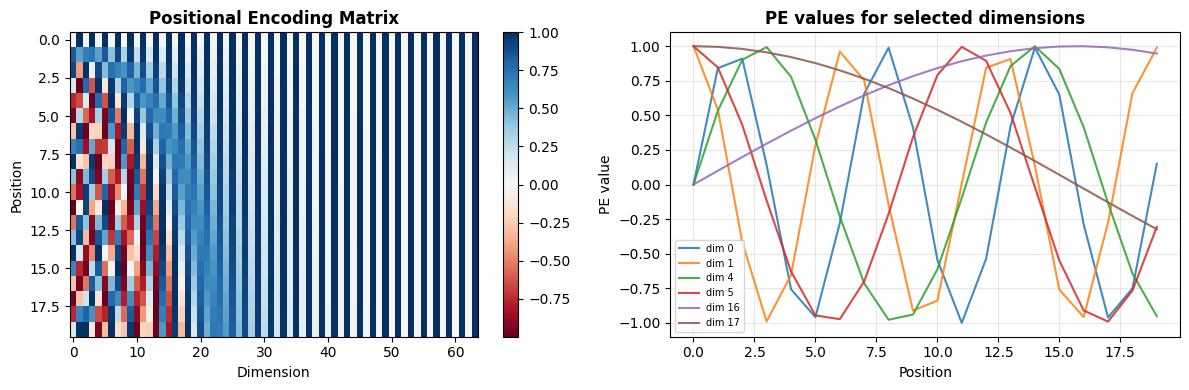

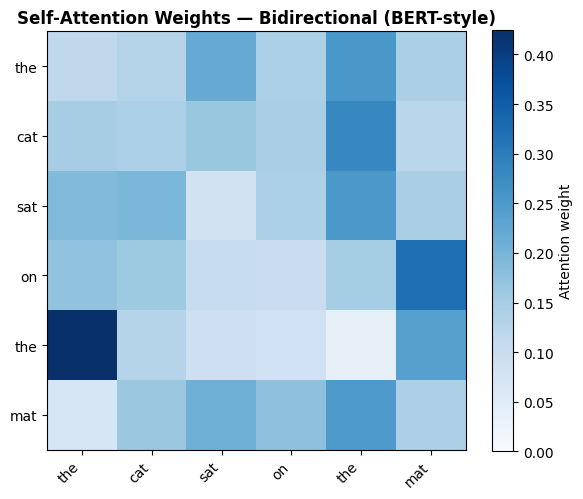

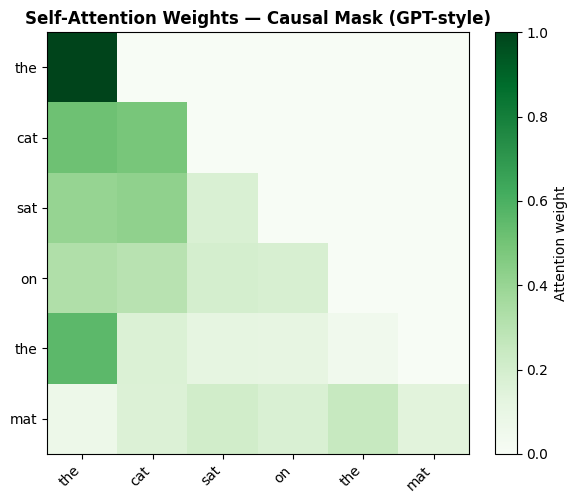

=== BPE Tokenisation Demo ===
Initial tokenisation: [['l', 'o', 'w', '</w>'], ['l', 'o', 'w', 'e', 'r', '</w>'], ['l', 'o', 'w', 'e', 's', 't', '</w>'], ['l', 'o', 'w', 'e', 's', 't', '</w>']] …

  Merge 1: ('w', 'e') → 'we'  (count=6)
  Merge 2: ('l', 'o') → 'lo'  (count=5)
  Merge 3: ('lo', 'we') → 'lowe'  (count=4)
  Merge 4: ('s', 't') → 'st'  (count=4)
  Merge 5: ('st', '</w>') → 'st</w>'  (count=4)
  Merge 6: ('st</w>', '</w>') → 'st</w></w>'  (count=4)


[['lo', 'w', '</w>'],
 ['lowe', 'r', '</w>'],
 ['lowe', 'st</w></w>', '</w>'],
 ['lowe', 'st</w></w>', '</w>'],
 ['lowe', 'st</w></w>', '</w>'],
 ['n', 'e', 'w', '</w>'],
 ['n', 'e', 'we', 'r', '</w>'],
 ['n', 'e', 'we', 'st</w></w>', '</w>']]

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ── Scaled Dot-Product Attention (pure NumPy) ─────────────────────────────────
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def attention(Q, K, V, mask=None):
    """Q,K,V: (seq, d_k)"""
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)           # (seq, seq)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)  # apply causal mask
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

# ── Sinusoidal Positional Encoding ────────────────────────────────────────────
def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    pos = np.arange(seq_len)[:, None]
    i   = np.arange(d_model // 2)[None, :]
    div = np.power(10000.0, 2 * i / d_model)
    PE[:, 0::2] = np.sin(pos / div)
    PE[:, 1::2] = np.cos(pos / div)
    return PE

seq_len, d_model = 20, 64
PE = positional_encoding(seq_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(PE, aspect="auto", cmap="RdBu")
axes[0].set_xlabel("Dimension"); axes[0].set_ylabel("Position")
axes[0].set_title("Positional Encoding Matrix", fontweight="bold")
plt.colorbar(im, ax=axes[0])

for dim in [0, 1, 4, 5, 16, 17]:
    axes[1].plot(PE[:, dim], label=f"dim {dim}", alpha=0.85)
axes[1].set_xlabel("Position"); axes[1].set_ylabel("PE value")
axes[1].set_title("PE values for selected dimensions", fontweight="bold")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Attention on a toy sentence ───────────────────────────────────────────────
sentence = "the cat sat on the mat".split()
T = len(sentence)
d_k = 8

np.random.seed(7)
# Random embeddings (would be learned in practice)
X = np.random.randn(T, d_k)
W_Q = np.random.randn(d_k, d_k) * 0.3
W_K = np.random.randn(d_k, d_k) * 0.3
W_V = np.random.randn(d_k, d_k) * 0.3

Q = X @ W_Q
K = X @ W_K
V = X @ W_V
out, weights = attention(Q, K, V)

plt.figure(figsize=(6, 5))
plt.imshow(weights, cmap="Blues", vmin=0, vmax=weights.max())
plt.colorbar(label="Attention weight")
plt.xticks(range(T), sentence, rotation=45, ha="right")
plt.yticks(range(T), sentence)
plt.title("Self-Attention Weights — Bidirectional (BERT-style)", fontweight="bold")
plt.tight_layout(); plt.show()

# ── Causal (GPT-style) attention mask ────────────────────────────────────────
causal_mask = np.tril(np.ones((T, T), dtype=bool))
out_causal, weights_causal = attention(Q, K, V, mask=causal_mask)

plt.figure(figsize=(6, 5))
plt.imshow(weights_causal, cmap="Greens", vmin=0)
plt.colorbar(label="Attention weight")
plt.xticks(range(T), sentence, rotation=45, ha="right")
plt.yticks(range(T), sentence)
plt.title("Self-Attention Weights — Causal Mask (GPT-style)", fontweight="bold")
plt.tight_layout(); plt.show()

# ── Minimal BPE tokeniser (3 merge rounds) ───────────────────────────────────
def bpe_encode(corpus, n_merges=8):
    vocab = [list(w) + ["</w>"] for w in corpus.split()]
    print(f"Initial tokenisation: {vocab[:4]} …\n")
    for step in range(n_merges):
        pairs = Counter()
        for word in vocab:
            for a, b in zip(word[:-1], word[1:]):
                pairs[(a, b)] += 1
        if not pairs: break
        best = max(pairs, key=pairs.get)
        new_symbol = "".join(best)
        vocab = [[new_symbol if (w[i]==best[0] and w[i+1]==best[1]) else w[i]
                  for i in range(len(w)-1)
                  if not (i > 0 and w[i-1]==best[0] and w[i]==best[1])]
                 + [w[-1]] for w in vocab]
        vocab = [list(w) if isinstance(w, str) else w for w in vocab]
        print(f"  Merge {step+1}: {best} → '{new_symbol}'  (count={pairs[best]})")
    return vocab

from collections import Counter
print("=== BPE Tokenisation Demo ===")
bpe_corpus = "low lower lowest lowest lowest new newer newest"
bpe_encode(bpe_corpus, n_merges=6)

<a name="generation"></a>
## 8. Text Generation & Decoding Strategies

### Language Model Probability
An autoregressive LM factorises the joint probability of a sequence:

$$P(w_1,\ldots,w_T) = \prod_{t=1}^{T} P(w_t \mid w_1,\ldots,w_{t-1})$$

Training minimises **cross-entropy** (negative log-likelihood):

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log P(w_t \mid w_{<t})$$

---

### Decoding Strategies

| Strategy | Description | Pros | Cons |
|----------|-------------|------|------|
| **Greedy** | Always pick $\arg\max P(w_t)$ | Fast, deterministic | Repetitive, misses diverse paths |
| **Beam search** | Keep top-$k$ partial sequences | Better quality | Still deterministic, slow for large $k$ |
| **Temperature sampling** | Sample from $P_T(w) \propto P(w)^{1/T}$ | Controllable diversity | High $T$ → incoherent |
| **Top-$k$ sampling** | Sample from top-$k$ logits only | Avoids low-prob words | Fixed $k$ may be too broad/narrow |
| **Nucleus / Top-$p$** | Sample from smallest set where $\sum P \geq p$ | Adaptive, high quality | Slightly complex |

### Temperature Scaling

$$P_T(w_i) = \frac{\exp(\text{logit}_i / T)}{\sum_j \exp(\text{logit}_j / T)}$$

- $T \to 0$: greedy (peaked distribution)  
- $T = 1$: standard sampling  
- $T > 1$: flatter, more random

---

### Perplexity
Intrinsic evaluation metric — lower is better:

$$\text{PPL} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T}\log P(w_t|w_{<t})\right) = 2^{H(P,Q)}$$

A perplexity of $k$ means the model is on average as "confused" as a uniform distribution over $k$ choices.

=== Bigram Language Model — Decoding Strategies ===

Greedy    (T=0.01): to be or not to be or to be that is the mind
Sampling  (T=1.0) : to outrageous no nobler or we end to arms tis a take be
Hot       (T=2.0) : to outrageous no nobler or we end to and tis a take by
Top-k=3          : to die to die to take arms whether end whether end whether end
Nucleus p=0.9    : to question no no or troubles by them and them a slings be


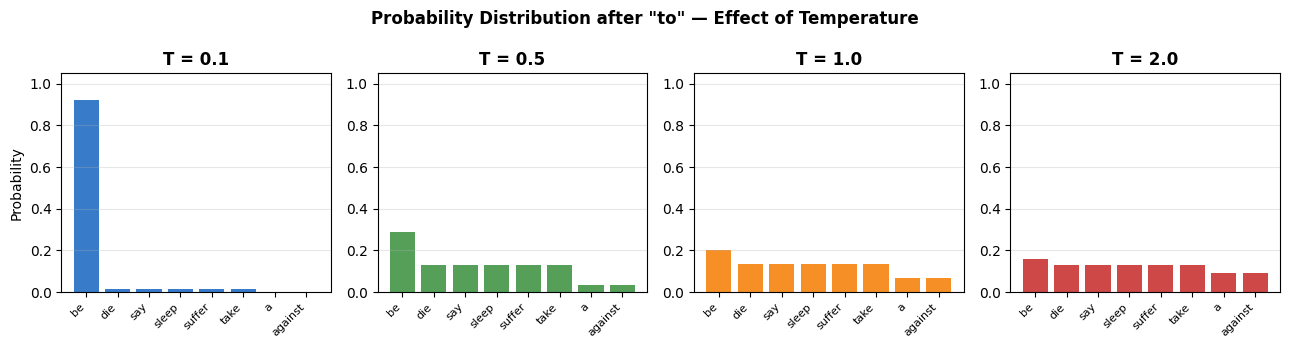


Perplexity on 'to be or not to be': 16.88
(Uniform baseline: 36)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# ── Train a bigram language model on tiny Shakespeare corpus ──────────────────
corpus = ("to be or not to be that is the question "
          "whether tis nobler in the mind to suffer "
          "the slings and arrows of outrageous fortune "
          "or to take arms against a sea of troubles "
          "and by opposing end them to die to sleep "
          "no more and by a sleep to say we end")

tokens = corpus.split()
vocab  = sorted(set(tokens))
v2i    = {w: i for i, w in enumerate(vocab)}
V      = len(vocab)

# Build bigram counts
bigrams = defaultdict(Counter)
for a, b in zip(tokens[:-1], tokens[1:]):
    bigrams[a][b] += 1

def bigram_logprobs(context_word):
    counts = bigrams[context_word]
    total  = sum(counts.values()) + V   # Laplace smoothing
    return {w: np.log((counts.get(w, 0) + 1) / total) for w in vocab}

# ── Decoding functions ────────────────────────────────────────────────────────
def sample_token(logprobs, temperature=1.0, top_k=None, top_p=None, seed=None):
    """Sample next token from log-probability dict."""
    if seed is not None: np.random.seed(seed)
    words  = list(logprobs.keys())
    logits = np.array([logprobs[w] for w in words])
    # Temperature
    logits = logits / temperature
    probs  = np.exp(logits - logits.max())
    probs /= probs.sum()
    # Top-k
    if top_k is not None:
        top_idx = np.argsort(probs)[-top_k:]
        mask = np.zeros_like(probs); mask[top_idx] = 1
        probs = probs * mask; probs /= probs.sum()
    # Top-p (nucleus)
    if top_p is not None:
        sorted_idx = np.argsort(-probs)
        cumsum = np.cumsum(probs[sorted_idx])
        cutoff = sorted_idx[np.searchsorted(cumsum, top_p)]
        mask = np.zeros_like(probs)
        mask[sorted_idx[:np.where(sorted_idx == cutoff)[0][0]+1]] = 1
        probs = probs * mask; probs /= probs.sum()
    return np.random.choice(words, p=probs)

def generate(seed_word, n=12, temperature=1.0, top_k=None, top_p=None, rng_seed=0):
    out = [seed_word]
    for i in range(n):
        lp = bigram_logprobs(out[-1])
        tok = sample_token(lp, temperature=temperature,
                           top_k=top_k, top_p=top_p, seed=rng_seed+i)
        out.append(tok)
    return " ".join(out)

print("=== Bigram Language Model — Decoding Strategies ===\n")
print(f"Greedy    (T=0.01): {generate('to', temperature=0.01)}")
print(f"Sampling  (T=1.0) : {generate('to', temperature=1.0)}")
print(f"Hot       (T=2.0) : {generate('to', temperature=2.0)}")
print(f"Top-k=3          : {generate('to', temperature=1.0, top_k=3)}")
print(f"Nucleus p=0.9    : {generate('to', temperature=1.0, top_p=0.9)}")

# ── Visualise temperature effect on probability distributions ─────────────────
context = "to"
lp = bigram_logprobs(context)
top8 = sorted(lp, key=lp.get, reverse=True)[:8]
base_logits = np.array([lp[w] for w in top8])

temps = [0.1, 0.5, 1.0, 2.0]
colors = ["#1565C0","#388E3C","#F57C00","#C62828"]
fig, axes = plt.subplots(1, len(temps), figsize=(13, 3.5), sharey=False)
for ax, T_val, color in zip(axes, temps, colors):
    logits = base_logits / T_val
    probs  = np.exp(logits - logits.max())
    probs /= probs.sum()
    ax.bar(range(len(top8)), probs, color=color, alpha=0.85)
    ax.set_xticks(range(len(top8))); ax.set_xticklabels(top8, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"T = {T_val}", fontweight="bold")
    ax.set_ylabel("Probability" if ax == axes[0] else "")
    ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
fig.suptitle(f'Probability Distribution after "{context}" — Effect of Temperature', fontweight="bold")
plt.tight_layout(); plt.show()

# ── Perplexity on held-out text ───────────────────────────────────────────────
test_tokens = "to be or not to be".split()
log_prob = 0.0
for a, b in zip(test_tokens[:-1], test_tokens[1:]):
    lp = bigram_logprobs(a)
    log_prob += lp[b]
ppl = np.exp(-log_prob / (len(test_tokens) - 1))
print(f"\nPerplexity on 'to be or not to be': {ppl:.2f}")
print(f"(Uniform baseline: {V:.0f})")